Loading base dataset...
Processing ChatGPT-5.4...
Processing Nemotron-Medical...
Processing Llama3-OpenBio...
Processing Llama3-Med42...
Processing Mistral-8x7b...
Processing Gemini 3.1...


C:\Users\Mohak\AppData\Local\Temp\ipykernel_16564\1400193194.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x='Model', y='Accuracy', data=df_overall_sorted_acc, palette='viridis')


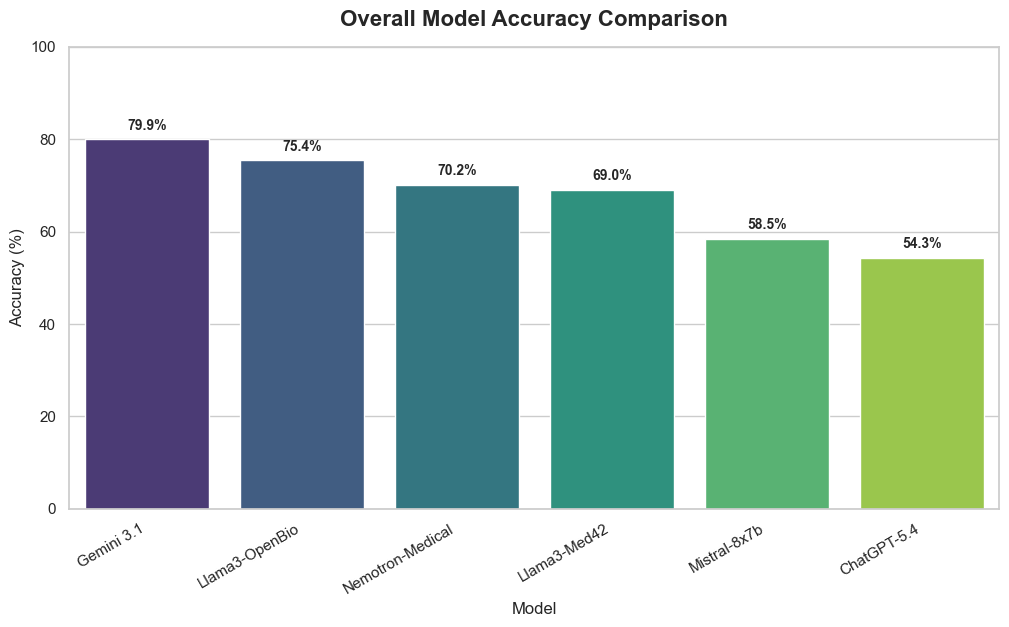

C:\Users\Mohak\AppData\Local\Temp\ipykernel_16564\1400193194.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='Model', y='Hallucinations', data=df_overall_sorted_hall, palette='magma')


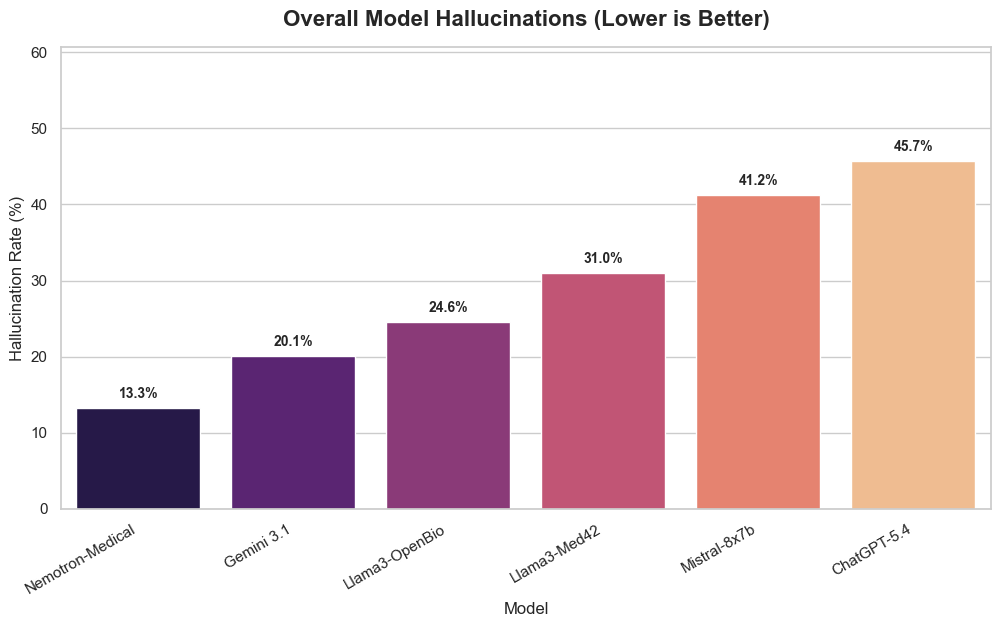

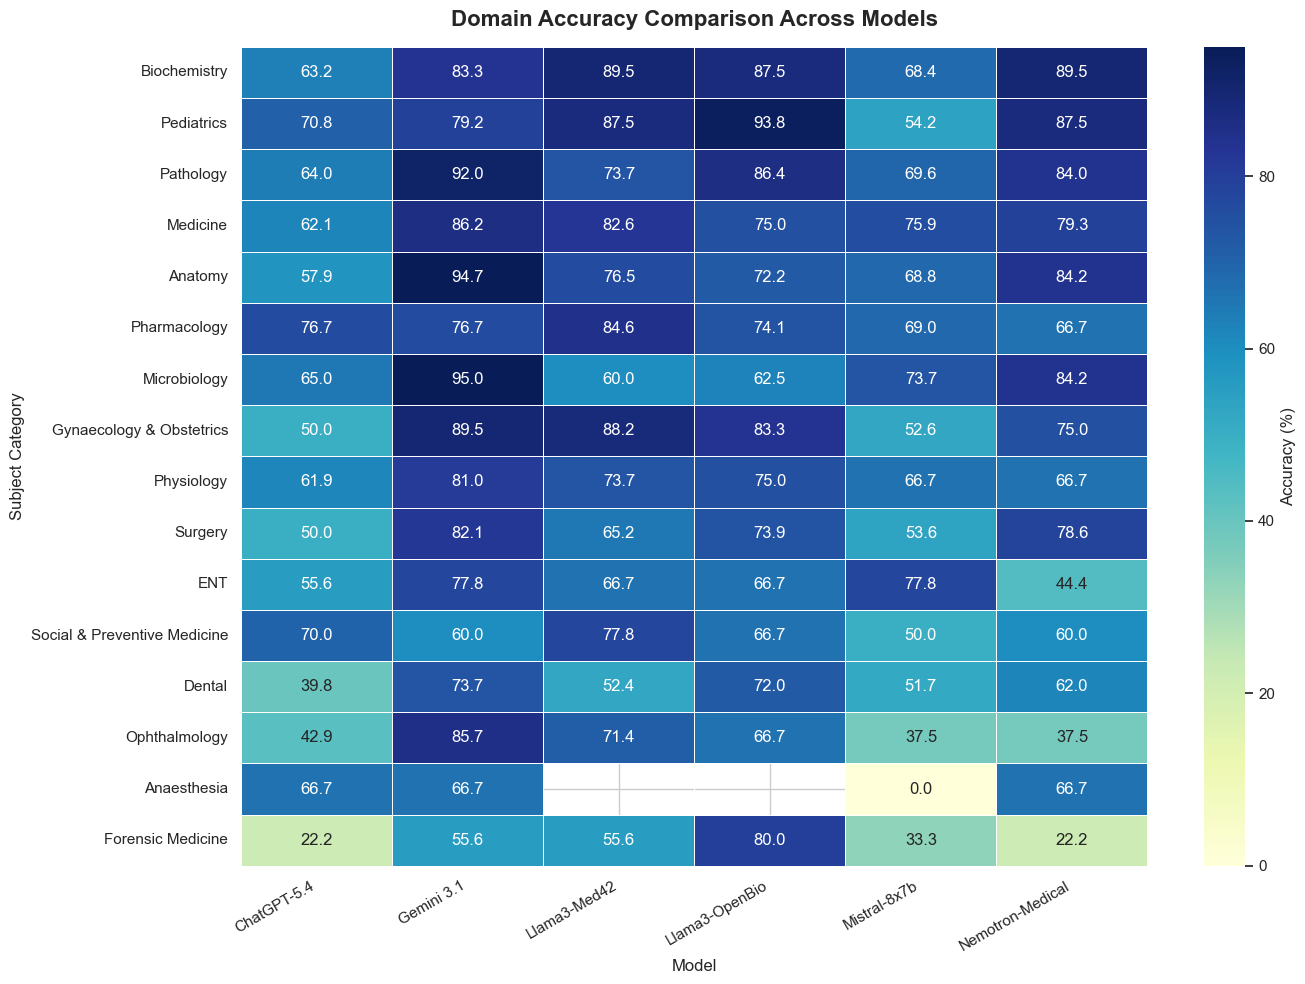

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compare_multiple_models(dataset_path):
    print("Loading base dataset...")
    df_dataset = pd.read_parquet(dataset_path)
    df_dataset['question_clean'] = df_dataset['question'].str.strip().str.lower()

    # Configuration for all your files, managing their different column names
    model_configs = {
        "GPT-5.4.csv": {"name": "ChatGPT-5.4", "correct": "correct_letter", "pred": "majority_letter"},
        "Nemotron-Medical.csv": {"name": "Nemotron-Medical", "correct": "correct_letter", "pred": "consensus_letter"},
        "Llama3-Open-Bio.csv": {"name": "Llama3-OpenBio", "correct": "correct_letter", "pred": "majority_letter"},
        "medmcqa_med42_70b_Q8.csv": {"name": "Llama3-Med42", "correct": "correct_letter", "pred": "majority_letter"},
        "mistral-7x8b.csv": {"name": "Mistral-8x7b", "correct": "true_letter", "pred": "pred_letter"},
        "Gemini-3.1.csv": {"name": "Gemini 3.1", "correct": "correct_letter", "pred": "majority_letter"},
    }

    overall_results = []
    category_results = []

    for file_name, config in model_configs.items():
        try:
            print(f"Processing {config['name']}...")
            df_model = pd.read_csv(file_name)
            
            # Standardize column names based on the config map above
            df_model = df_model.rename(columns={
                config['correct']: 'standard_correct', 
                config['pred']: 'standard_pred'
            })
            
            df_model['question_clean'] = df_model['question'].str.strip().str.lower()
            
            # Merge to get categories
            df_merged = pd.merge(df_model, df_dataset[['question_clean', 'subject_name']], 
                                 on='question_clean', how='inner')
            
            # Remove 'X' rows
            df_clean = df_merged[(df_merged['standard_correct'] != 'X') & (df_merged['standard_pred'] != 'X')].copy()
            
            # Ensure boolean values are calculated as numbers (0 or 1)
            df_clean['is_correct'] = df_clean['is_correct'].astype(int)
            
            # Mistral might use 0/1, others might use True/False strings. Let's make it safe:
            if df_clean['hallucinated'].dtype == 'object':
                df_clean['hallucinated'] = df_clean['hallucinated'].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
            else:
                df_clean['hallucinated'] = df_clean['hallucinated'].astype(int)

            # --- Calculate Overall ---
            acc = df_clean['is_correct'].mean() * 100
            hall = df_clean['hallucinated'].mean() * 100
            overall_results.append({"Model": config['name'], "Accuracy": acc, "Hallucinations": hall})

            # --- Calculate Categorical ---
            cat_stats = df_clean.groupby('subject_name').agg(
                Accuracy=('is_correct', lambda x: x.mean() * 100),
                Count=('is_correct', 'count')
            ).reset_index()
            
            # Filter categories with at least 5 questions to prevent 100% flukes
            cat_stats = cat_stats[cat_stats['Count'] >= 5]
            cat_stats['Model'] = config['name']
            category_results.append(cat_stats)
            
        except Exception as e:
            print(f"Error processing {file_name}: {e}")

    # Combine all results into DataFrames
    df_overall = pd.DataFrame(overall_results)
    df_categories = pd.concat(category_results, ignore_index=True)

    # ==========================================
    # VISUALIZATIONS
    # ==========================================
    sns.set_theme(style="whitegrid")

    # 1. Overall Accuracy Comparison
    plt.figure(figsize=(12, 6))
    df_overall_sorted_acc = df_overall.sort_values('Accuracy', ascending=False)
    ax1 = sns.barplot(x='Model', y='Accuracy', data=df_overall_sorted_acc, palette='viridis')
    plt.title('Overall Model Accuracy Comparison', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.ylim(0, 100)
    plt.xticks(rotation=30, ha='right')
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')
    plt.show()

    # 2. Overall Hallucinations Comparison (Lower is Better)
    plt.figure(figsize=(12, 6))
    df_overall_sorted_hall = df_overall.sort_values('Hallucinations', ascending=True)
    ax2 = sns.barplot(x='Model', y='Hallucinations', data=df_overall_sorted_hall, palette='magma')
    plt.title('Overall Model Hallucinations (Lower is Better)', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Hallucination Rate (%)', fontsize=12)
    plt.ylim(0, max(df_overall['Hallucinations']) + 15)
    plt.xticks(rotation=30, ha='right')
    for p in ax2.patches:
        ax2.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')
    plt.show()

    # 3. Domain Accuracy Heatmap
    # Pivot the data so Rows = Categories, Columns = Models, Values = Accuracy
    pivot_df = df_categories.pivot(index='subject_name', columns='Model', values='Accuracy')
    
    # Sort the heatmap by the categories with the highest average accuracy across all models
    pivot_df['Average'] = pivot_df.mean(axis=1)
    pivot_df = pivot_df.sort_values('Average', ascending=False).drop(columns=['Average'])
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Accuracy (%)'}, linewidths=.5)
    plt.title('Domain Accuracy Comparison Across Models', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Subject Category', fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    return df_overall, pivot_df

# Run the pipeline (make sure validation-00000-of-00001.parquet is in the same folder)
overall_summary, domain_summary = compare_multiple_models('validation-00000-of-00001.parquet')